<a href="https://colab.research.google.com/github/RAVIAPTISWETHA/COVID-19-Detection-from-Chest-X-ray-Images-Using-CNN-/blob/main/CNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Libraries


In [32]:
pip install keras-tuner

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import os
from PIL import Image
import random
import hashlib
import shutil
import cv2
from sklearn.utils import class_weight
print("Libraries imported successfully.")

Libraries imported successfully.


In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Dataset Path and Folder Check


In [35]:
dataset_path = "/content/drive/MyDrive/Covid19-Pneumonia-Normal Chest X-Ray Images Dataset"

print("Folders inside dataset:\n")
print(os.listdir(dataset_path))

Folders inside dataset:

['COVID', 'PNEUMONIA', 'NORMAL']


# Count Images in Each Class

In [36]:
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"{class_name}: {num_images} images")

COVID: 1626 images
PNEUMONIA: 1800 images
NORMAL: 1802 images


# Remove Duplicate Images


In [37]:
clean_dataset_path = "/content/drive/MyDrive/clean_dataset"
duplicates_path = "/content/drive/MyDrive/duplicate_images"

classes = ["COVID", "NORMAL", "PNEUMONIA"]


def is_already_processed(path, classes):
    if not os.path.exists(path):
        return False

    for cls in classes:
        class_path = os.path.join(path, cls)
        if not os.path.exists(class_path) or len(os.listdir(class_path)) == 0:
            return False
    return True


if is_already_processed(clean_dataset_path, classes):
    print("Dataset already cleaned. Skipping processing.")
else:
    print("Processing dataset (removing duplicates)...")

    # Create folders
    for cls in classes:
        os.makedirs(os.path.join(clean_dataset_path, cls), exist_ok=True)
        os.makedirs(os.path.join(duplicates_path, cls), exist_ok=True)

    hash_dict = {}
    duplicates_count = 0

    for cls in classes:
        class_path = os.path.join(dataset_path, cls)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            with open(img_path, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()


            if file_hash not in hash_dict:
                hash_dict[file_hash] = img_path
                shutil.copy(img_path, os.path.join(clean_dataset_path, cls, img_name))


            else:
                shutil.copy(img_path, os.path.join(duplicates_path, cls, img_name))
                duplicates_count += 1

    print("Done")
    print("Duplicates moved:", duplicates_count)

Dataset already cleaned. Skipping processing.


# Updated Class Counts


In [38]:
print("\nCleaned Dataset Distribution:\n")

class_counts = {}
total_images = 0

for cls in os.listdir(clean_dataset_path):
    class_path = os.path.join(clean_dataset_path, cls)

    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        class_counts[cls] = count
        total_images += count
        print(f"{cls}: {count}")

print("\nTotal images:", total_images)


Cleaned Dataset Distribution:

COVID: 1537
NORMAL: 1671
PNEUMONIA: 1791

Total images: 4999


# Display Sample Images

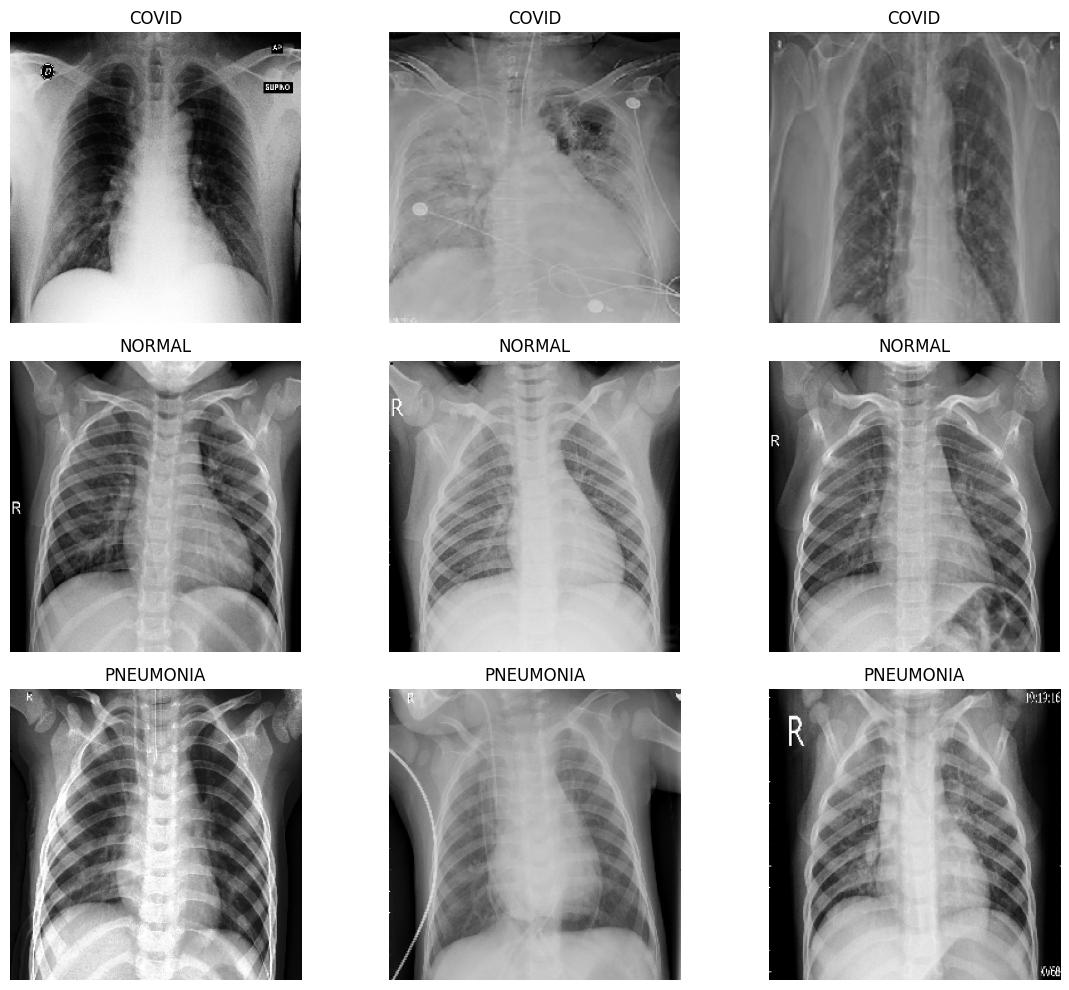

In [39]:
classes = ["COVID", "NORMAL", "PNEUMONIA"]

plt.figure(figsize=(12,10))

plot_index = 1

for cls in classes:
    class_path = os.path.join(clean_dataset_path, cls)

    images = [img for img in os.listdir(class_path) if img.endswith(('.png', '.jpg', '.jpeg'))]

    sample_images = random.sample(images, 3)

    for img_name in sample_images:
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path).convert("RGB")

        plt.subplot(3, 3, plot_index)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')

        plot_index += 1

plt.tight_layout()
plt.show()

# Bar Chart


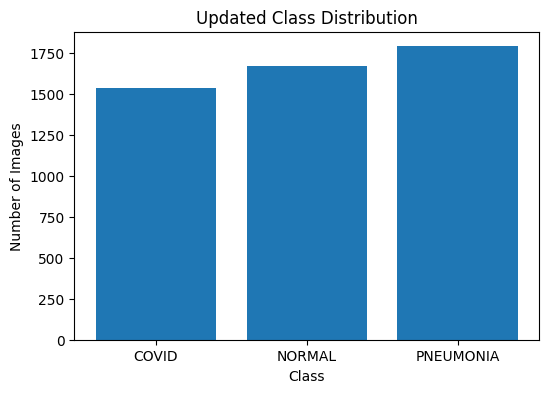

In [40]:
plt.figure(figsize=(6,4))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Updated Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

# Pie Chart

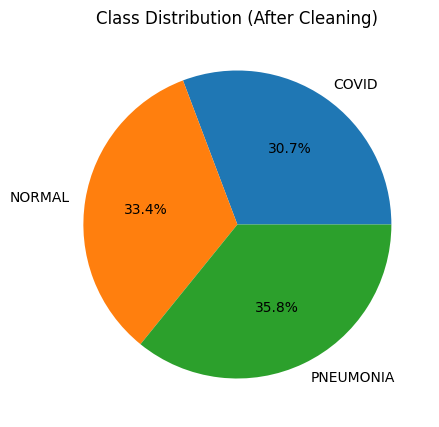

In [41]:
plt.figure(figsize=(5,5))
plt.pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%')
plt.title("Class Distribution (After Cleaning)")
plt.show()

# Image Size Check

In [42]:
for cls in ["COVID", "NORMAL", "PNEUMONIA"]:
    class_path = os.path.join(dataset_path, cls)
    img_name = os.listdir(class_path)[0]
    img = Image.open(os.path.join(class_path, img_name))
    print(f"{cls} image size:", img.size)

COVID image size: (232, 232)
NORMAL image size: (256, 256)
PNEUMONIA image size: (256, 256)


# Pixel Intensity Histogram

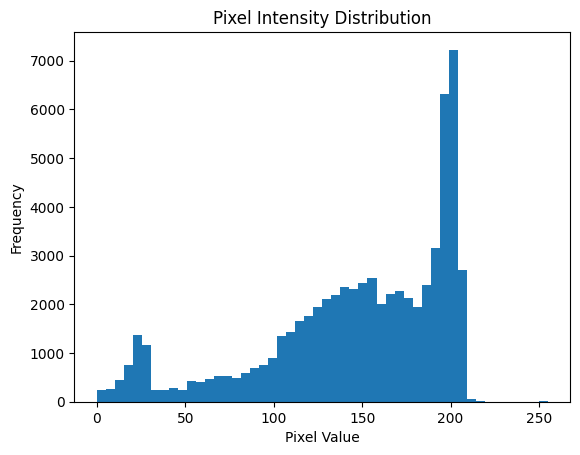

In [43]:
img_array = np.array(img.convert("L"))  # grayscale

plt.hist(img_array.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

# Image Preprocessing and Data Generators


In [44]:
base_dir = "/content/drive/MyDrive/clean_dataset"
split_base_path = "/content/covid_split"

train_path = os.path.join(split_base_path, "train")
val_path = os.path.join(split_base_path, "val")
test_path = os.path.join(split_base_path, "test")

classes = ["COVID", "NORMAL", "PNEUMONIA"]

img_size = (224, 224)
batch_size = 32


def is_split_ready(split_base_path, classes):
    for split in ["train", "val", "test"]:
        for cls in classes:
            path = os.path.join(split_base_path, split, cls)

            if not os.path.exists(path):
                return False

            if len(os.listdir(path)) == 0:
                return False

    return True



if is_split_ready(split_base_path, classes):
    print("Dataset split already exists. Skipping splitting step.")
else:
    print("Creating dataset split")

    # Create folders
    for split in ["train", "val", "test"]:
        for cls in classes:
            os.makedirs(os.path.join(split_base_path, split, cls), exist_ok=True)

    train_ratio = 0.7
    val_ratio = 0.15

    for cls in classes:
        class_path = os.path.join(base_dir, cls)
        images = [img for img in os.listdir(class_path)
                  if img.endswith(('.png', '.jpg', '.jpeg'))]

        random.shuffle(images)

        total = len(images)
        train_end = int(train_ratio * total)
        val_end = int((train_ratio + val_ratio) * total)

        train_imgs = images[:train_end]
        val_imgs = images[train_end:val_end]
        test_imgs = images[val_end:]

        for img in train_imgs:
            shutil.copy(os.path.join(class_path, img),
                        os.path.join(train_path, cls, img))

        for img in val_imgs:
            shutil.copy(os.path.join(class_path, img),
                        os.path.join(val_path, cls, img))

        for img in test_imgs:
            shutil.copy(os.path.join(class_path, img),
                        os.path.join(test_path, cls, img))

    print("Dataset split completed successfully.")

Dataset split already exists. Skipping splitting step.


# Data generators


In [45]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


print("\nClass indices:")
print(train_generator.class_indices)

x_batch, y_batch = next(train_generator)
print("\nImage batch shape:", x_batch.shape)
print("Label batch shape:", y_batch.shape)

Found 3497 images belonging to 3 classes.
Found 751 images belonging to 3 classes.
Found 751 images belonging to 3 classes.

Class indices:
{'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 3)


# Apply Weights During Model Training

In [46]:
class_labels = train_generator.classes

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)

class_weights_dict = dict(enumerate(class_weights))

print("Calculated Class Weights:", class_weights_dict)

Calculated Class Weights: {0: np.float64(1.0843410852713178), 1: np.float64(0.9971485600228115), 2: np.float64(0.9303006118648577)}


# Baseline CNN Model


In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

baseline_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

baseline_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

# Train Baseline CNN Model


In [48]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Folder to save models
save_dir = "/content/drive/MyDrive/saved_models"
os.makedirs(save_dir, exist_ok=True)

# Create subdirectories for baseline model checkpoints
baseline_checkpoint_dir = os.path.join(save_dir, "baseline_cnn", "checkpoints")
os.makedirs(baseline_checkpoint_dir, exist_ok=True)
best_model_path = os.path.join(baseline_checkpoint_dir, "best_baseline_cnn_model.keras")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath=best_model_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    mode='min',
    verbose=1
)

# Check if baseline model already exists
if os.path.exists(best_model_path):
    print(f"Baseline CNN model already found at {best_model_path}. Skipping training.")
    history_baseline_weighted = None
else:
    print("Training Baseline CNN model...")
    history_baseline_weighted = baseline_cnn.fit(
        train_generator,
        validation_data=val_generator,
        epochs=80,
        callbacks=[early_stopping, reduce_lr, checkpoint],
        class_weight=class_weights_dict
    )

Training Baseline CNN model...
Epoch 1/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.6259 - loss: 1.1196
Epoch 1: val_loss improved from None to 0.22396, saving model to /content/drive/MyDrive/saved_models/baseline_cnn/checkpoints/best_baseline_cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/saved_models/baseline_cnn/checkpoints/best_baseline_cnn_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 47s 389ms/step - accuracy: 0.7409 - loss: 0.6904 - val_accuracy: 0.9161 - val_loss: 0.2240 - learning_rate: 0.0010
Epoch 2/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.8607 - loss: 0.3792
Epoch 2: val_loss improved from 0.22396 to 0.18731, saving model to /content/drive/MyDrive/saved_models/baseline_cnn/checkpoints/best_baseline_cnn_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/saved_models/baseline_cnn/checkpoints/best_baseline_cnn_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 40s 366ms/step - accuracy: 0.8602 - loss: 0.3732 - va

# Save Baseline CNN Model


In [49]:
loaded_model = tf.keras.models.load_model(best_model_path)
print("Model loaded successfully from:", best_model_path)

Model loaded successfully from: /content/drive/MyDrive/saved_models/baseline_cnn/checkpoints/best_baseline_cnn_model.keras


# Evaluate Baseline CNN on Test Set


In [50]:
test_loss, test_accuracy = loaded_model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.9680 - loss: 0.1320
Test Loss: 0.1319749504327774
Test Accuracy: 0.9680426120758057


# Confusion Matrix and Classification Report


In [51]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = baseline_cnn.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step
Confusion Matrix:
 [[226   2   3]
 [  3 241   7]
 [  2   7 260]]

Classification Report:

              precision    recall  f1-score   support

       COVID       0.98      0.98      0.98       231
      NORMAL       0.96      0.96      0.96       251
   PNEUMONIA       0.96      0.97      0.96       269

    accuracy                           0.97       751
   macro avg       0.97      0.97      0.97       751
weighted avg       0.97      0.97      0.97       751



# Plot Confusion Matrix (Heatmap)


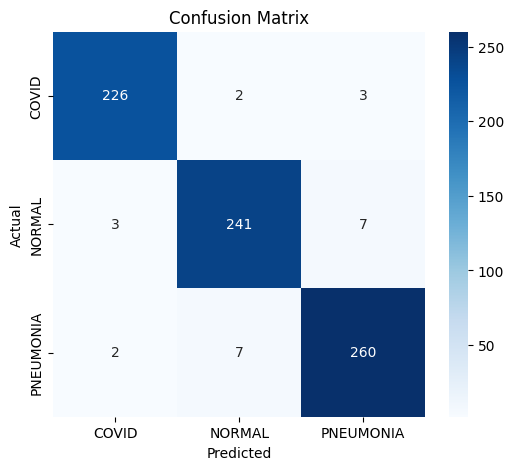

In [52]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Training vs Validation Accuracy


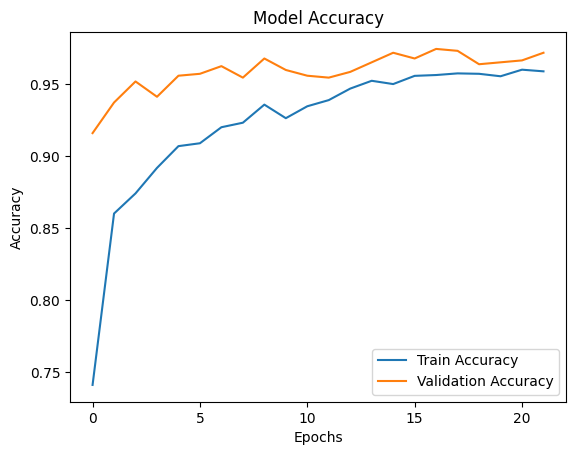

In [53]:
if history_baseline_weighted:
    plt.plot(history_baseline_weighted.history['accuracy'], label='Train Accuracy')
    plt.plot(history_baseline_weighted.history['val_accuracy'], label='Validation Accuracy')

    plt.title("Model Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()
else:
    print("Training history not available for Baseline CNN (model was loaded from disk or training was skipped).")

# Training vs Validation Loss


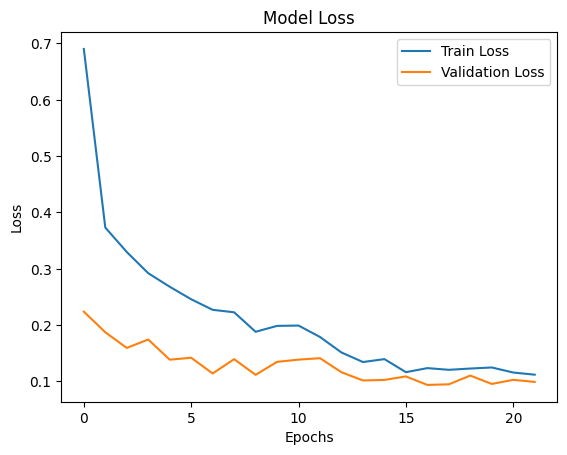

In [54]:
if history_baseline_weighted:
    plt.plot(history_baseline_weighted.history['loss'], label='Train Loss')
    plt.plot(history_baseline_weighted.history['val_loss'], label='Validation Loss')

    plt.title("Model Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
else:
    print("Training history not available for Baseline CNN (model was loaded from disk or training was skipped).")

In [55]:
import keras_tuner as kt

def build_model(hp):
    model = Sequential()

    model.add(Conv2D(hp.Int('conv_1_filters', min_value=32, max_value=128, step=32),
                     (3, 3), activation='relu', input_shape=(224, 224, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(hp.Int('conv_2_filters', min_value=64, max_value=256, step=64),
                     (3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    if hp.Boolean('use_third_conv'):
        model.add(Conv2D(hp.Int('conv_3_filters', min_value=128, max_value=512, step=128),
                         (3, 3), activation='relu'))
        model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())

    model.add(Dense(hp.Int('dense_units', min_value=64, max_value=256, step=64), activation='relu'))

    model.add(Dropout(hp.Float('dropout_rate', min_value=0.2, max_value=0.6, step=0.1)))

    model.add(Dense(3, activation='softmax'))

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [56]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    directory='keras_tuner_dir',
    project_name='covid_xray_tuning'
)

tuner.search_space_summary()

Reloading Tuner from keras_tuner_dir/covid_xray_tuning/tuner0.json
Search space summary
Default search space size: 7
conv_1_filters (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
conv_2_filters (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 64, 'sampling': 'linear'}
use_third_conv (Boolean)
{'default': False, 'conditions': []}
dense_units (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 64, 'sampling': 'linear'}
dropout_rate (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.6, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}
conv_3_filters (Int)
{'default': None, 'conditions': [], 'min_value': 128, 'max_value': 512, 'step': 128, 'sampling': 'linear'}


In [57]:
early_stopping_tuning = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_tuning = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

tuner.search(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stopping_tuning, reduce_lr_tuning],
    class_weight=class_weights_dict
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Optimal Hyperparameters:")
for hp_name, hp_value in best_hps.values.items():
    print(f"  {hp_name}: {hp_value}")

Trial 30 Complete [00h 00m 17s]

Best val_accuracy So Far: 0.9720372557640076
Total elapsed time: 02h 19m 30s
Optimal Hyperparameters:
  conv_1_filters: 32
  conv_2_filters: 64
  use_third_conv: False
  dense_units: 256
  dropout_rate: 0.2
  learning_rate: 0.001
  conv_3_filters: 512
  tuner/epochs: 20
  tuner/initial_epoch: 0
  tuner/bracket: 0
  tuner/round: 0


### Build and Train the Best Model

In [58]:
best_model = tuner.hypermodel.build(best_hps)

best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,796,163 (182.33 MB)

 Trainable params: 47,796,163 (182.33 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
# Create subdirectories for tuned model checkpoints
tuned_checkpoint_dir = os.path.join(save_dir, "tuned_cnn", "checkpoints")
os.makedirs(tuned_checkpoint_dir, exist_ok=True)
best_model_path_tuned = os.path.join(tuned_checkpoint_dir, "best_tuned_cnn_model.keras")

checkpoint_tuned = ModelCheckpoint(
    filepath=best_model_path_tuned,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    mode='min',
    verbose=1
)

if os.path.exists(best_model_path_tuned):
    print(f"Tuned model already found at {best_model_path_tuned}. Skipping training.")
    history_tuned = None
else:
    print("Training tuned model")
    history_tuned = best_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=80,
        callbacks=[early_stopping, reduce_lr, checkpoint_tuned],
        class_weight=class_weights_dict
    )

Training tuned model
Epoch 1/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.6092 - loss: 2.3320
Epoch 1: val_loss improved from None to 0.21155, saving model to /content/drive/MyDrive/saved_models/tuned_cnn/checkpoints/best_tuned_cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/saved_models/tuned_cnn/checkpoints/best_tuned_cnn_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 47s 395ms/step - accuracy: 0.7484 - loss: 1.0042 - val_accuracy: 0.9348 - val_loss: 0.2116 - learning_rate: 0.0010
Epoch 2/80
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.8761 - loss: 0.3395
Epoch 2: val_loss improved from 0.21155 to 0.16941, saving model to /content/drive/MyDrive/saved_models/tuned_cnn/checkpoints/best_tuned_cnn_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/saved_models/tuned_cnn/checkpoints/best_tuned_cnn_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 42s 380ms/step - accuracy: 0.8782 - loss: 0.3467 - val_accuracy: 0.9441 - val_loss: 0.1

### Evaluate the Tuned Model on Test Set

In [60]:
loaded_tuned_model = tf.keras.models.load_model(best_model_path_tuned)
print("Tuned model loaded successfully from:", best_model_path_tuned)

test_loss_tuned, test_accuracy_tuned = loaded_tuned_model.evaluate(test_generator)

print("\nTest Loss (Tuned Model):", test_loss_tuned)
print("Test Accuracy (Tuned Model):", test_accuracy_tuned)

Tuned model loaded successfully from: /content/drive/MyDrive/saved_models/tuned_cnn/checkpoints/best_tuned_cnn_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.9121 - loss: 0.2435

Test Loss (Tuned Model): 0.2435256540775299
Test Accuracy (Tuned Model): 0.9121171832084656


### Confusion Matrix and Classification Report for Tuned Model

In [61]:
y_pred_tuned = loaded_tuned_model.predict(test_generator)
y_pred_classes_tuned = np.argmax(y_pred_tuned, axis=1)

y_true_tuned = test_generator.classes

class_labels_tuned = list(test_generator.class_indices.keys())

cm_tuned = confusion_matrix(y_true_tuned, y_pred_classes_tuned)
print("Confusion Matrix (Tuned Model):\n", cm_tuned)

print("\nClassification Report (Tuned Model):\n")
print(classification_report(y_true_tuned, y_pred_classes_tuned, target_names=class_labels_tuned))

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step
Confusion Matrix (Tuned Model):
 [[218   4   9]
 [  8 228  15]
 [ 12  18 239]]

Classification Report (Tuned Model):

              precision    recall  f1-score   support

       COVID       0.92      0.94      0.93       231
      NORMAL       0.91      0.91      0.91       251
   PNEUMONIA       0.91      0.89      0.90       269

    accuracy                           0.91       751
   macro avg       0.91      0.91      0.91       751
weighted avg       0.91      0.91      0.91       751



### Plot Confusion Matrix (Heatmap) for Tuned Model

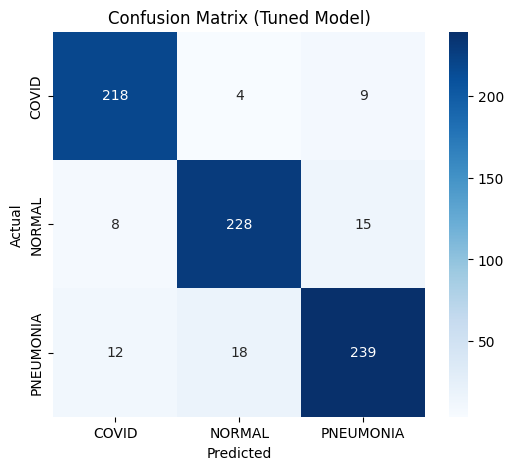

In [62]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_tuned,
            yticklabels=class_labels_tuned)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Tuned Model)")
plt.show()

### Training vs Validation Accuracy for Tuned Model

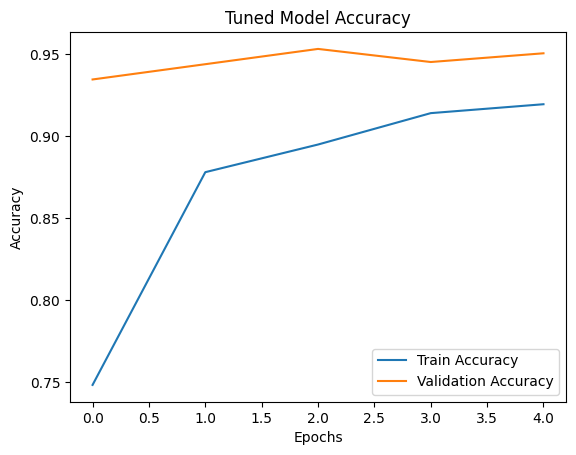

In [63]:
if history_tuned:
    plt.plot(history_tuned.history['accuracy'], label='Train Accuracy')
    plt.plot(history_tuned.history['val_accuracy'], label='Validation Accuracy')

    plt.title("Tuned Model Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()
else:
    print("Training history not available for Tuned Model (model was loaded from disk or training was skipped).")

### Training vs Validation Loss for Tuned Model

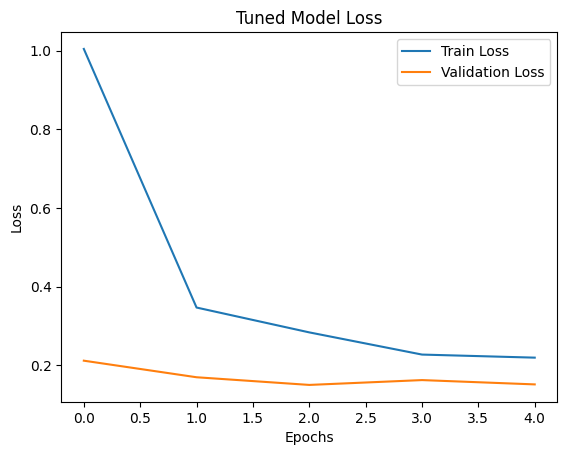

In [64]:
if history_tuned:
    plt.plot(history_tuned.history['loss'], label='Train Loss')
    plt.plot(history_tuned.history['val_loss'], label='Validation Loss')

    plt.title("Tuned Model Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
else:
    print("Training history not available for Tuned Model (model was loaded from disk or training was skipped).")

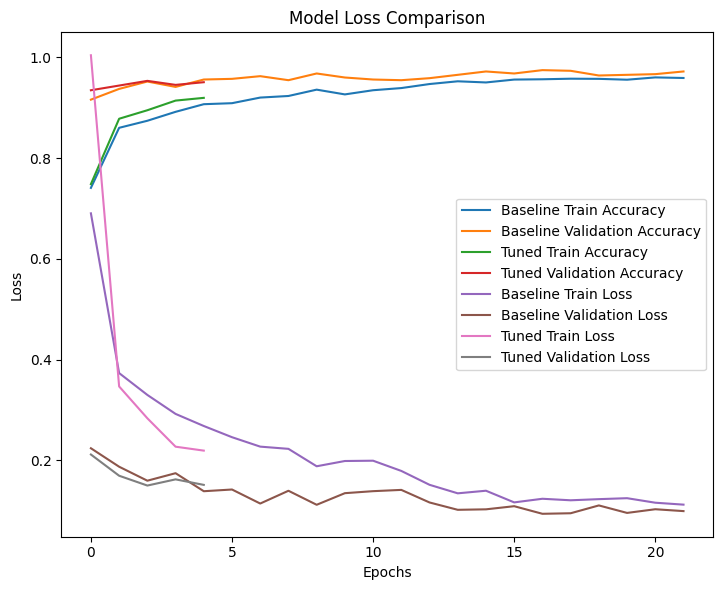

In [65]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
if history_baseline_weighted:
    plt.plot(history_baseline_weighted.history['accuracy'], label='Baseline Train Accuracy')
    plt.plot(history_baseline_weighted.history['val_accuracy'], label='Baseline Validation Accuracy')
if history_tuned:
    plt.plot(history_tuned.history['accuracy'], label='Tuned Train Accuracy')
    plt.plot(history_tuned.history['val_accuracy'], label='Tuned Validation Accuracy')

if history_baseline_weighted or history_tuned:
    plt.title("Model Accuracy Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
else:
    print("Training history not available for either Baseline CNN or Tuned Model (models were loaded from disk or training was skipped).")

if history_baseline_weighted:
    plt.plot(history_baseline_weighted.history['loss'], label='Baseline Train Loss')
    plt.plot(history_baseline_weighted.history['val_loss'], label='Baseline Validation Loss')
if history_tuned:
    plt.plot(history_tuned.history['loss'], label='Tuned Train Loss')
    plt.plot(history_tuned.history['val_loss'], label='Tuned Validation Loss')

if history_baseline_weighted or history_tuned:
    plt.title("Model Loss Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

plt.tight_layout()
plt.show()

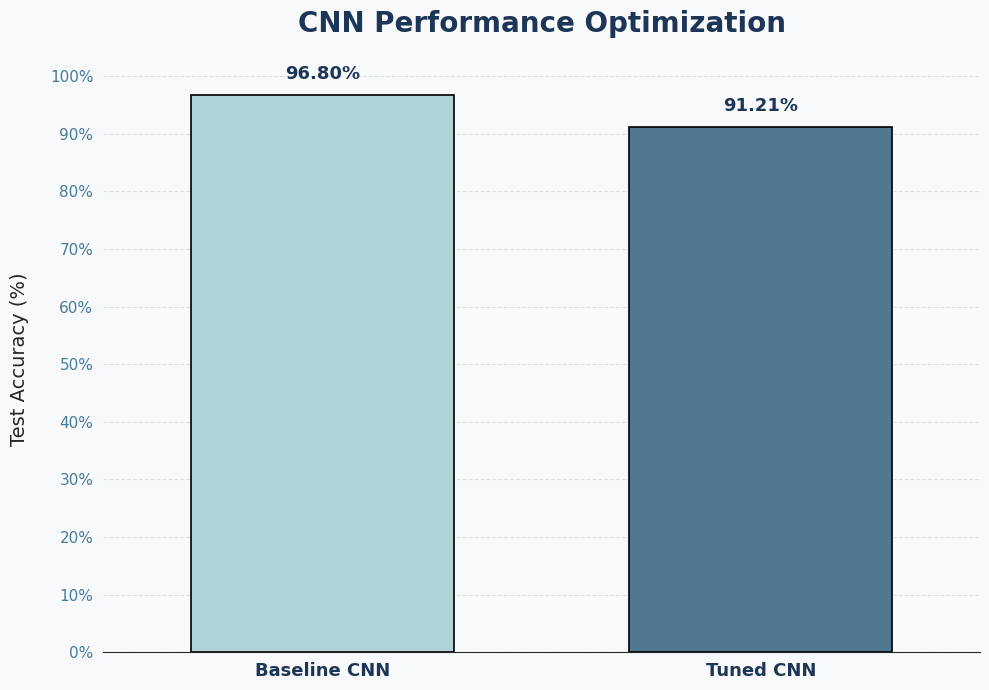

In [72]:
model_names = ['Baseline CNN', 'Tuned CNN']
accuracies = [test_accuracy, test_accuracy_tuned]

sns.set_style("white")
plt.figure(figsize=(10, 7), facecolor='#F8F9FA')
ax = plt.gca()
ax.set_facecolor('#F8F9FA')
colors = ["#A8DADC", "#457B9D"]

# 3. Create the barplot
barplot = sns.barplot(
    x=model_names,
    y=accuracies,
    hue=model_names,
    palette=colors,
    edgecolor='black',
    linewidth=1.2,
    legend=False,
    width=0.6
)

plt.title('CNN Performance Optimization', fontsize=20, fontweight='bold', pad=25, color='#1D3557')
plt.ylabel('Test Accuracy (%)', fontsize=14, labelpad=15, fontweight='500')
plt.xlabel('', fontsize=0)

plt.yticks(np.arange(0, 1.1, 0.1), [f'{x*100:.0f}%' for x in np.arange(0, 1.1, 0.1)], fontsize=11, color='#457B9D')
plt.xticks(fontsize=13, fontweight='bold', color='#1D3557')

ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.2)
sns.despine(left=True, bottom=False)

for p in barplot.patches:
    val = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2.,
        val + 0.02,
        f'{val:.2%}',
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight='bold',
        color='#1D3557'
    )
plt.tight_layout()
plt.show()

In [76]:
for i, layer in enumerate(baseline_cnn.layers):
    print(i, layer.name, layer.__class__.__name__)

0 conv2d_3 Conv2D
1 max_pooling2d_3 MaxPooling2D
2 conv2d_4 Conv2D
3 max_pooling2d_4 MaxPooling2D
4 conv2d_5 Conv2D
5 max_pooling2d_5 MaxPooling2D
6 flatten_1 Flatten
7 dense_2 Dense
8 dropout_1 Dropout
9 dense_3 Dense


Upload an image (JPG, PNG, JPEG) to get a prediction and Grad-CAM visualization:


Saving swet.png to swet.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted: NORMAL (Confidence: 83.53%)
Using last convolutional layer: conv2d_4


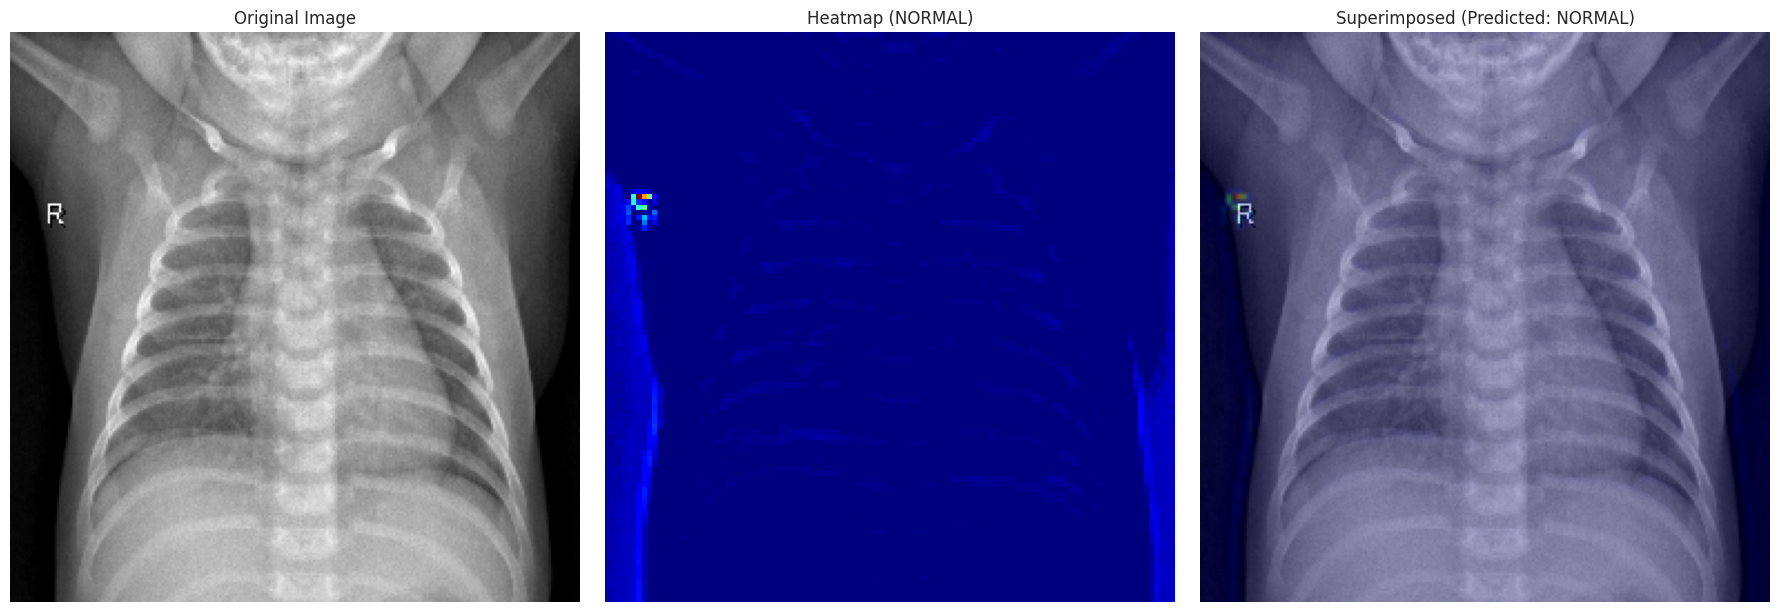

In [94]:
from google.colab import files
import io

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model_features = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=model.get_layer(last_conv_layer_name).output
    )
    classifier_input_shape = grad_model_features.output.shape[1:]
    classifier_input = tf.keras.Input(shape=classifier_input_shape)

    x = classifier_input
    for layer in model.layers[model.layers.index(model.get_layer(last_conv_layer_name)) + 1:]:
        x = layer(x)
    grad_model_classifier = tf.keras.models.Model(inputs=classifier_input, outputs=x)

    with tf.GradientTape() as tape:
        last_conv_layer_output = grad_model_features(img_array)
        tape.watch(last_conv_layer_output)

        preds = grad_model_classifier(last_conv_layer_output)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)

    jet = plt.colormaps["jet"]

    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.utils.array_to_img(superimposed_img)

    return superimposed_img

def predict_and_gradcam(uploaded_file, model, class_names, img_size):
    img = Image.open(io.BytesIO(uploaded_file)).convert("RGB")
    original_img_for_display = np.array(img)
    img_resized = img.resize(img_size)
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    _ = model(img_array)

    predictions = model.predict(img_array)
    predicted_class_idx = np.argmax(predictions)
    predicted_class_name = class_names[predicted_class_idx]
    confidence = np.max(predictions) * 100

    print(f"Predicted: {predicted_class_name} (Confidence: {confidence:.2f}%)")

    last_conv_layer_name = None
    for layer in reversed(model.layers):
        if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.SeparableConv2D)):
            last_conv_layer_name = layer.name
            break

    if last_conv_layer_name is None:
        print("Could not find a convolutional layer in the model for Grad-CAM.")
        plt.figure(figsize=(6, 6))
        plt.imshow(original_img_for_display)
        plt.title(f"Prediction: {predicted_class_name} (Confidence: {confidence:.2f}%)")
        plt.axis('off')
        plt.show()
    else:
        print(f"Using last convolutional layer: {last_conv_layer_name}")
        heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, predicted_class_idx)

        plt.figure(figsize=(18, 6))

        plt.subplot(1, 3, 1)
        plt.imshow(original_img_for_display)
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(heatmap, cmap='jet')
        plt.title(f"Heatmap ({predicted_class_name})")
        plt.axis('off')

        superimposed_img = display_gradcam(original_img_for_display, heatmap)
        plt.subplot(1, 3, 3)
        plt.imshow(superimposed_img)
        plt.title(f"Superimposed (Predicted: {predicted_class_name})")
        plt.axis('off')
        plt.tight_layout()
        plt.show()


print("Upload an image (JPG, PNG, JPEG) to get a prediction and Grad-CAM visualization:")
uploaded = files.upload()

for fn in uploaded.keys():
    predict_and_gradcam(
        uploaded[fn],
        loaded_tuned_model,
        list(test_generator.class_indices.keys()),
        img_size
    )